# Stage 3: Convert Car Damages Dataset to YOLO Panel Segmentation Format

This notebook converts Dataset A: Car Damages into a YOLO segmentation dataset for the Stage 3 panel/component segmenter.

Conversion rules:

- Source annotations: Supervisely-style JSON polygons
- Class order: taken from `meta.json`
- Interior polygon holes: subtracted using Shapely
- Split: 80% train / 10% val / 10% test
- Seed: 42
- Output format: YOLO instance segmentation labels

For a smoke test:

```python
OUT_DIR = Path("data/processed/stage3/car_damages_panel_debug")
LIMIT = 20

In [23]:
from pathlib import Path

RAW_ROOT = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/archive/Car damages dataset")

OUT_DIR = Path("/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel")

SEED = 42

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

MIN_AREA_PX = 25.0

LIMIT = 0

OVERWRITE = True

In [24]:
import json
import random
import re
import shutil
from collections import Counter

import cv2
from shapely.geometry import GeometryCollection, MultiPolygon, Polygon, box


def sanitize_stem(stem: str, fallback: str) -> str:
    """Sanitize a filename stem for safer YOLO dataset paths."""
    stem = stem.strip()

    if not stem:
        return fallback

    stem = stem.replace(" ", "_")
    stem = re.sub(r"[^A-Za-z0-9._-]+", "_", stem)
    stem = re.sub(r"_+", "_", stem)
    stem = stem.strip("._")

    if not stem:
        return fallback

    return stem


def load_classes(meta_path: Path):
    """Load official class names and IDs from meta.json."""
    with open(meta_path, "r") as f:
        meta = json.load(f)

    classes = meta.get("classes")

    if not isinstance(classes, list) or len(classes) == 0:
        raise ValueError(f"Could not find a valid classes list in {meta_path}")

    names = []
    class_id_to_idx = {}
    title_to_idx = {}

    for idx, item in enumerate(classes):
        title = item.get("title")

        if not title:
            raise ValueError(f"Class at index {idx} in {meta_path} has no title.")

        names.append(title)

        if "id" in item:
            class_id_to_idx[item["id"]] = idx

        title_to_idx[title] = idx

    return names, class_id_to_idx, title_to_idx


def ensure_empty_dir(path: Path, overwrite: bool):
    """Ensure output directory is empty or create it."""
    if path.exists():
        if not overwrite:
            raise RuntimeError(
                f"Output directory already exists: {path}. "
                "Set OVERWRITE = True if you want to replace it."
            )

        if path.is_dir():
            shutil.rmtree(path)
        else:
            path.unlink()

    path.mkdir(parents=True, exist_ok=True)


def clean_ring(ring, width, height):
    """Clip ring coordinates to image bounds."""
    points = []

    for point in ring:
        if not isinstance(point, (list, tuple)) or len(point) < 2:
            continue

        x = float(point[0])
        y = float(point[1])

        x = max(0.0, min(float(width), x))
        y = max(0.0, min(float(height), y))

        points.append((x, y))

    return points


def geometry_to_polygons(exterior, interior, width, height, report):
    """Convert one annotation object to one or more Shapely polygons.

    Interior holes are subtracted from the exterior polygon.
    """
    if len(exterior) < 3:
        report["skipped_exterior_too_small"] += 1
        return []

    exterior_pts = clean_ring(exterior, width, height)

    if len(exterior_pts) < 3:
        report["skipped_exterior_too_small"] += 1
        return []

    try:
        result = Polygon(exterior_pts)

        if not result.is_valid:
            result = result.buffer(0)

    except Exception:
        report["skipped_invalid_exterior"] += 1
        return []

    image_box = box(0, 0, width, height)

    if interior:
        report["input_polygons_with_holes"] += 1

        for hole_ring in interior:
            if len(hole_ring) < 3:
                report["skipped_invalid_hole"] += 1
                continue

            hole_pts = clean_ring(hole_ring, width, height)

            if len(hole_pts) < 3:
                report["skipped_invalid_hole"] += 1
                continue

            try:
                hole = Polygon(hole_pts)

                if not hole.is_valid:
                    hole = hole.buffer(0)

                result = result.difference(hole)

                if not result.is_valid:
                    result = result.buffer(0)

            except Exception:
                report["skipped_failed_hole_difference"] += 1
                continue

    try:
        result = result.intersection(image_box)

        if not result.is_valid:
            result = result.buffer(0)

    except Exception:
        report["skipped_failed_clip"] += 1
        return []

    if result.is_empty:
        report["skipped_empty_after_processing"] += 1
        return []

    polygons = []

    if isinstance(result, Polygon):
        polygons.append(result)

    elif isinstance(result, MultiPolygon):
        polygons.extend(result.geoms)

    elif isinstance(result, GeometryCollection):
        for geom in result.geoms:
            if isinstance(geom, Polygon):
                polygons.append(geom)

    else:
        report["skipped_unsupported_geometry"] += 1
        return []

    return polygons


def polygon_to_yolo_line(class_idx, polygon, width, height, min_area_px):
    """Convert a Shapely polygon to one YOLO segmentation label line."""
    if polygon.area < min_area_px:
        return None, "small"

    exterior = list(polygon.exterior.coords)

    if len(exterior) > 1 and exterior[0] == exterior[-1]:
        exterior = exterior[:-1]

    if len(exterior) < 3:
        return None, "too_few_points"

    coords = []

    for x, y in exterior:
        xn = max(0.0, min(1.0, x / float(width)))
        yn = max(0.0, min(1.0, y / float(height)))

        coords.append(f"{xn:.6f}")
        coords.append(f"{yn:.6f}")

    line = " ".join([str(class_idx)] + coords)

    return line, "ok"

In [25]:
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, (
    "Split ratios must sum to 1.0."
)

file1_dir = RAW_ROOT / "File1"
ann_dir = file1_dir / "ann"
img_dir = file1_dir / "img"
meta_path = RAW_ROOT / "meta.json"

assert ann_dir.exists(), f"Annotation directory not found: {ann_dir}"
assert img_dir.exists(), f"Image directory not found: {img_dir}"
assert meta_path.exists(), f"meta.json not found: {meta_path}"

names, class_id_to_idx, title_to_idx = load_classes(meta_path)

print(f"Loaded {len(names)} classes from meta.json:")
for idx, name in enumerate(names):
    print(f"{idx:>2}: {name}")

ensure_empty_dir(OUT_DIR, OVERWRITE)

for split in ["train", "val", "test"]:
    (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

ann_files = sorted(ann_dir.glob("*.json"))

if LIMIT > 0:
    ann_files = ann_files[:LIMIT]

n_total = len(ann_files)

assert n_total > 0, "No annotation files found."

n_test = int(round(n_total * TEST_RATIO))
n_val = int(round(n_total * VAL_RATIO))
n_train = n_total - n_val - n_test

assert n_train >= 0, "Invalid split counts."

file_order = [p.name[:-5] for p in ann_files]
rng = random.Random(SEED)
rng.shuffle(file_order)

train_set = set(file_order[:n_train])
val_set = set(file_order[n_train : n_train + n_val])
test_set = set(file_order[n_train + n_val :])

print()
print("Dataset split prepared.")
print(f"Output directory: {OUT_DIR}")
print(f"Total images: {n_total}")
print(f"Train: {len(train_set)}")
print(f"Val:   {len(val_set)}")
print(f"Test:  {len(test_set)}")

Loaded 21 classes from meta.json:
 0: Quarter-panel
 1: Front-wheel
 2: Back-window
 3: Trunk
 4: Front-door
 5: Rocker-panel
 6: Grille
 7: Windshield
 8: Front-window
 9: Back-door
10: Headlight
11: Back-wheel
12: Back-windshield
13: Hood
14: Fender
15: Tail-light
16: License-plate
17: Front-bumper
18: Back-bumper
19: Mirror
20: Roof

Dataset split prepared.
Output directory: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel
Total images: 998
Train: 798
Val:   100
Test:  100


In [26]:
report = {
    "source_root": str(RAW_ROOT),
    "output_dir": str(OUT_DIR),
    "seed": SEED,
    "split_ratios": {
        "train": TRAIN_RATIO,
        "val": VAL_RATIO,
        "test": TEST_RATIO,
    },
    "num_images_total": n_total,
    "split_counts": {
        "train": len(train_set),
        "val": len(val_set),
        "test": len(test_set),
    },
    "class_names": names,
    "images_written": 0,
    "labels_written": 0,
    "input_polygons": 0,
    "output_yolo_polygons": 0,
    "input_polygons_with_holes": 0,
    "output_polygon_counts_by_class": Counter(),
    "missing_images": [],
    "image_read_failures": [],
    "size_mismatches": [],
    "unknown_classes": Counter(),
    "filename_collisions": [],
    "skipped_non_polygon_objects": 0,
    "skipped_unknown_class": 0,
    "skipped_exterior_too_small": 0,
    "skipped_invalid_exterior": 0,
    "skipped_invalid_hole": 0,
    "skipped_failed_hole_difference": 0,
    "skipped_failed_clip": 0,
    "skipped_empty_after_processing": 0,
    "skipped_unsupported_geometry": 0,
    "skipped_small_polygons": 0,
    "skipped_too_few_points": 0,
}

used_output_names = {}

for idx, ann_file in enumerate(ann_files):
    # Example:
    # "Car damages 100.png.json" -> "Car damages 100.png"
    image_name = ann_file.name[:-5]

    image_path = img_dir / image_name

    if image_name in train_set:
        split = "train"
    elif image_name in val_set:
        split = "val"
    elif image_name in test_set:
        split = "test"
    else:
        raise RuntimeError(f"Could not assign split for: {image_name}")

    if not image_path.exists():
        report["missing_images"].append(image_name)
        continue

    img = cv2.imread(str(image_path))

    if img is None:
        report["image_read_failures"].append(image_name)
        continue

    actual_height, actual_width = img.shape[:2]

    with open(ann_file, "r") as f:
        ann = json.load(f)

    json_size = ann.get("size", {})
    json_height = json_size.get("height")
    json_width = json_size.get("width")

    if (json_height, json_width) != (actual_height, actual_width):
        report["size_mismatches"].append(
            {
                "image": image_name,
                "json_size": [json_height, json_width],
                "actual_size": [actual_height, actual_width],
            }
        )

    width = actual_width
    height = actual_height

    image_path_obj = Path(image_name)
    original_stem = image_path_obj.stem
    suffix = image_path_obj.suffix.lower() or ".jpg"

    base_sanitized_stem = sanitize_stem(original_stem, f"image_{idx:06d}")
    sanitized_stem = base_sanitized_stem
    sanitized_name = f"{sanitized_stem}{suffix}"

    if sanitized_name in used_output_names:
        report["filename_collisions"].append(
            {
                "output_name": sanitized_name,
                "existing_image": used_output_names[sanitized_name],
                "new_image": image_name,
            }
        )

        dup = 1

        while sanitized_name in used_output_names:
            sanitized_stem = f"{base_sanitized_stem}_dup{dup}"
            sanitized_name = f"{sanitized_stem}{suffix}"
            dup += 1

    used_output_names[sanitized_name] = image_name

    lines = []

    for obj in ann.get("objects", []):
        if obj.get("geometryType") != "polygon":
            report["skipped_non_polygon_objects"] += 1
            continue

        class_id = obj.get("classId")
        class_title = obj.get("classTitle")

        class_idx = None

        if class_id in class_id_to_idx:
            class_idx = class_id_to_idx[class_id]
        elif class_title in title_to_idx:
            class_idx = title_to_idx[class_title]
        else:
            report["skipped_unknown_class"] += 1
            report["unknown_classes"][str(class_title)] += 1
            continue

        points = obj.get("points", {})
        exterior = points.get("exterior") or []
        interior = points.get("interior") or []

        report["input_polygons"] += 1

        polygons = geometry_to_polygons(
            exterior=exterior,
            interior=interior,
            width=width,
            height=height,
            report=report,
        )

        for polygon in polygons:
            line, status = polygon_to_yolo_line(
                class_idx=class_idx,
                polygon=polygon,
                width=width,
                height=height,
                min_area_px=MIN_AREA_PX,
            )

            if status == "ok":
                lines.append(line)
                report["output_yolo_polygons"] += 1
                report["output_polygon_counts_by_class"][names[class_idx]] += 1

            elif status == "small":
                report["skipped_small_polygons"] += 1

            elif status == "too_few_points":
                report["skipped_too_few_points"] += 1

    # Copy image.
    shutil.copy2(
        image_path,
        OUT_DIR / "images" / split / sanitized_name,
    )
    report["images_written"] += 1

    # Write label file, even if empty.
    label_path = OUT_DIR / "labels" / split / f"{sanitized_stem}.txt"

    with open(label_path, "w") as f:
        if lines:
            f.write("\n".join(lines) + "\n")

    report["labels_written"] += 1

print("Conversion loop finished.")
print(f"Images written: {report['images_written']}")
print(f"Labels written: {report['labels_written']}")
print(f"Input polygons: {report['input_polygons']}")
print(f"Output YOLO polygons: {report['output_yolo_polygons']}")
print(f"Input polygons with holes: {report['input_polygons_with_holes']}")

Conversion loop finished.
Images written: 998
Labels written: 998
Input polygons: 15767
Output YOLO polygons: 15781
Input polygons with holes: 140


In [27]:
report["unknown_classes"] = dict(report["unknown_classes"])
report["output_polygon_counts_by_class"] = dict(
    report["output_polygon_counts_by_class"]
)

yaml_lines = [
    "# Generated by src/stage3/data/convert_car_damages_to_yolo.ipynb",
    "# Stage 3 panel/component segmentation dataset",
    f"path: {OUT_DIR.as_posix()}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "",
    f"nc: {len(names)}",
    "names:",
]

for idx, name in enumerate(names):
    yaml_lines.append(f'  {idx}: "{name}"')

yaml_path = OUT_DIR / "car_damages_panel.yaml"

with open(yaml_path, "w") as f:
    f.write("\n".join(yaml_lines) + "\n")

report_path = OUT_DIR / "conversion_report.json"

with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Dataset YAML written:")
print(yaml_path)
print()
print("Conversion report written:")
print(report_path)

Dataset YAML written:
/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/car_damages_panel.yaml

Conversion report written:
/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel/conversion_report.json


In [28]:
print("=" * 70)
print("Conversion Summary")
print("=" * 70)

print(f"Output directory: {OUT_DIR}")
print(f"Images written: {report['images_written']}")
print(f"Labels written: {report['labels_written']}")
print(f"Input polygons: {report['input_polygons']}")
print(f"Output YOLO polygons: {report['output_yolo_polygons']}")
print(f"Input polygons with holes: {report['input_polygons_with_holes']}")
print(f"Split counts: {report['split_counts']}")

print()
print("Output polygon counts by class:")

for class_name, count in sorted(
    report["output_polygon_counts_by_class"].items(),
    key=lambda item: -item[1],
):
    print(f"{class_name:<20} {count:>6}")

warnings = []

if report["missing_images"]:
    warnings.append(f"missing_images={len(report['missing_images'])}")

if report["image_read_failures"]:
    warnings.append(
        f"image_read_failures={len(report['image_read_failures'])}"
    )

if report["size_mismatches"]:
    warnings.append(f"size_mismatches={len(report['size_mismatches'])}")

if report["filename_collisions"]:
    warnings.append(f"filename_collisions={len(report['filename_collisions'])}")

if report["skipped_unknown_class"]:
    warnings.append(
        f"skipped_unknown_class={report['skipped_unknown_class']}"
    )

if report["skipped_small_polygons"]:
    warnings.append(
        f"skipped_small_polygons={report['skipped_small_polygons']}"
    )

print()

if warnings:
    print("Warnings:")
    for warning in warnings:
        print(warning)
else:
    print("No major warnings.")

Conversion Summary
Output directory: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/stage3/car_damages_panel
Images written: 998
Labels written: 998
Input polygons: 15767
Output YOLO polygons: 15781
Input polygons with holes: 140
Split counts: {'train': 798, 'val': 100, 'test': 100}

Output polygon counts by class:
Back-window            1236
Mirror                  986
Front-window            951
Fender                  937
Front-door              917
Headlight               915
Front-wheel             885
Back-wheel              865
Rocker-panel            860
Quarter-panel           856
Roof                    793
Back-door               723
Tail-light              721
Hood                    712
Front-bumper            706
Windshield              633
Grille                  578
Back-bumper             444
Trunk                   422
License-plate           370
Back-windshield         271

Warnings:
skipped_small_polygons=13


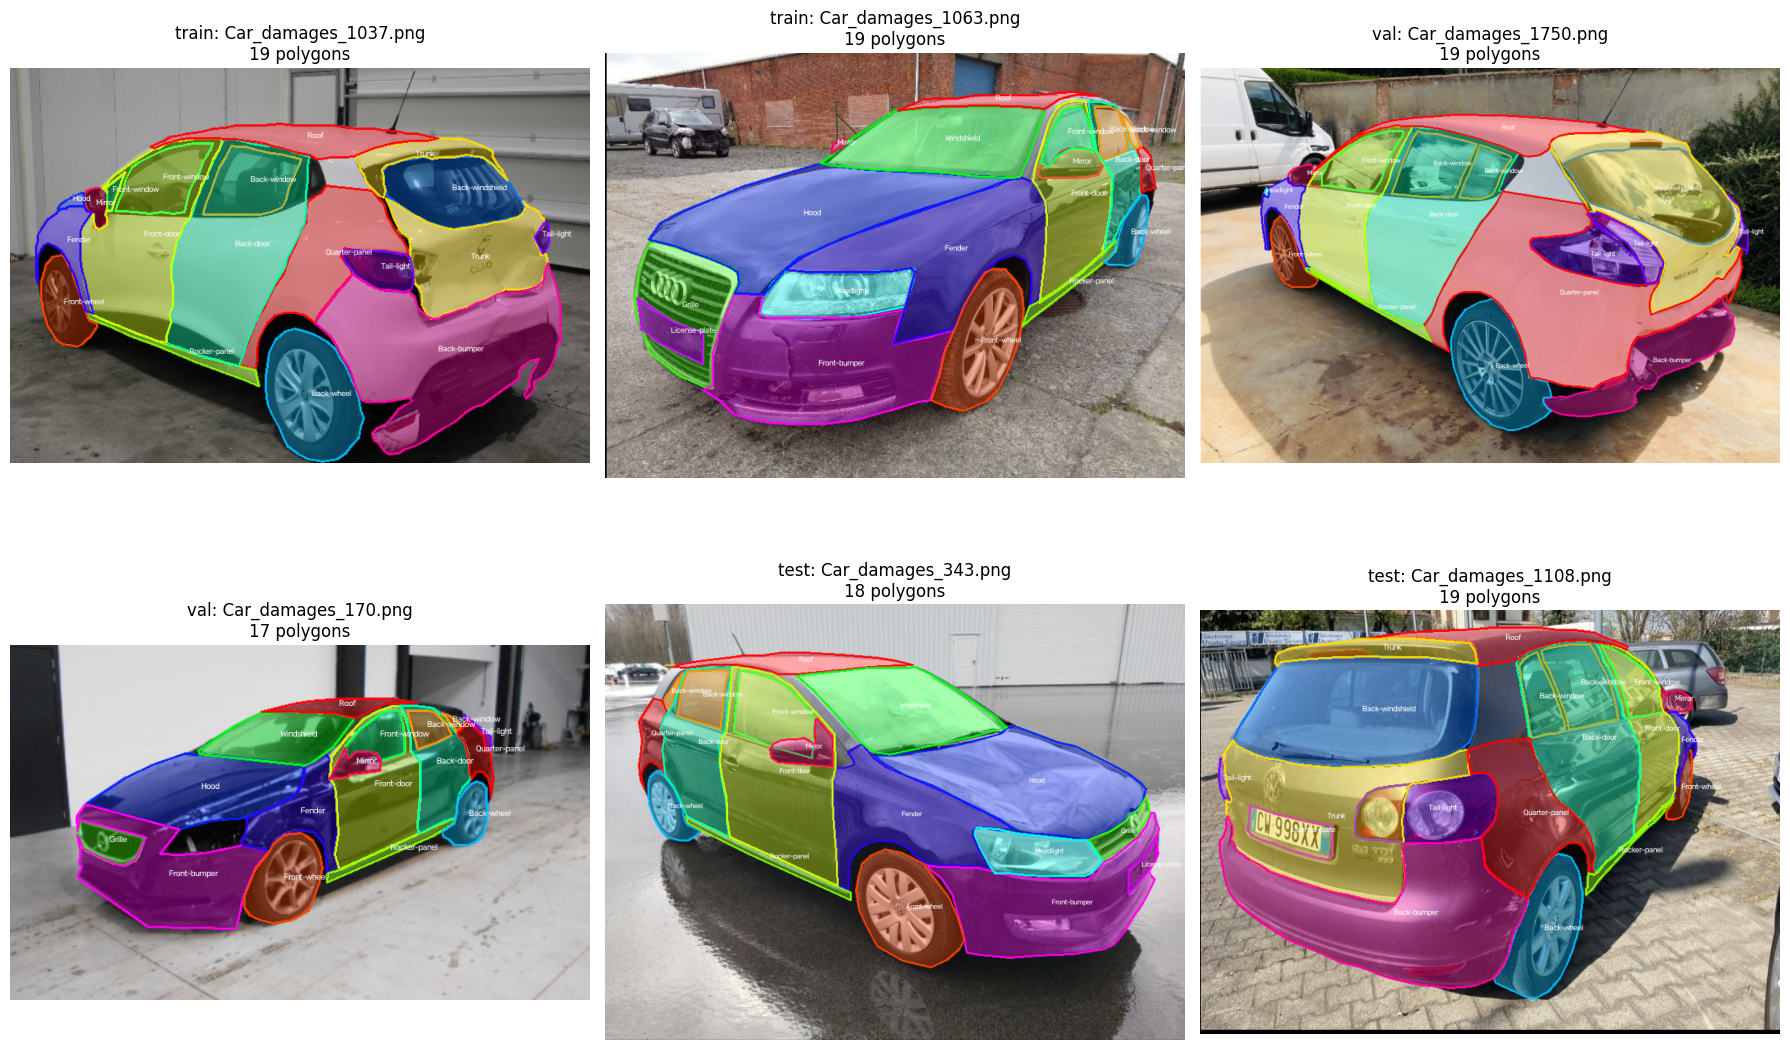

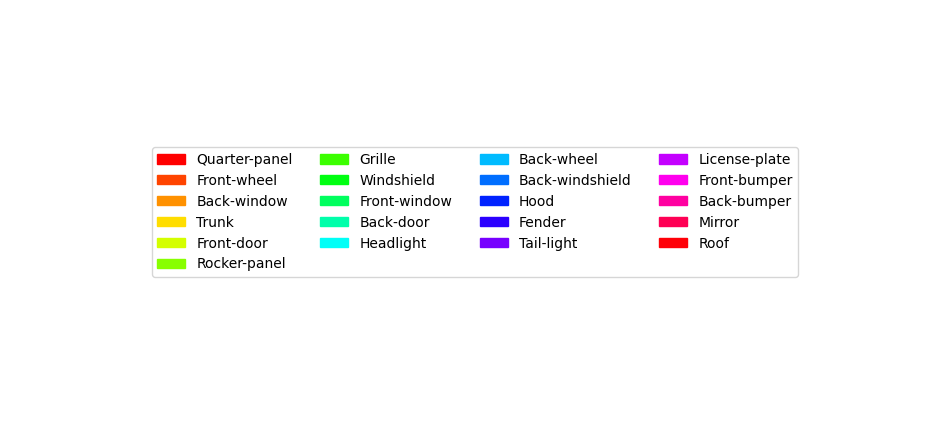

In [32]:
# Cell 8 — Dataset visualization (ground-truth YOLO labels)

import random

import cv2
import numpy as np

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
except ImportError as exc:
    raise RuntimeError(
        "matplotlib is required for visualization. "
        "Install it with: python -m pip install matplotlib"
    ) from exc


# Visualization settings
SAMPLES_PER_SPLIT = 2
VIS_SEED = 42
SHOW_CLASS_TEXT = True
MAX_COLUMNS = 3
FIGSIZE_PER_IMAGE = 6


def class_color(class_idx: int, num_classes: int):
    """Generate a deterministic color for a class index."""
    if num_classes <= 1:
        hue = 0
    else:
        hue = int(179 * class_idx / (num_classes - 1))

    hsv = np.uint8([[[hue, 255, 255]]])
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[0][0]

    return tuple(int(c) for c in bgr)


def read_yolo_label(label_path, width, height):
    """Read a YOLO segmentation label file and return polygon objects."""
    polygons = []

    if not label_path.exists():
        return polygons

    for line in label_path.read_text().splitlines():
        line = line.strip()

        if not line:
            continue

        parts = line.split()
        class_idx = int(parts[0])
        coords = list(map(float, parts[1:]))

        # Need at least 3 points: x1 y1 x2 y2 x3 y3
        if len(coords) < 6:
            continue

        pts = np.array(coords).reshape(-1, 2)

        pts[:, 0] *= width
        pts[:, 1] *= height

        pts = pts.astype(np.int32)

        polygons.append((class_idx, pts))

    return polygons


def draw_image_with_labels(image_path, label_path, class_names):
    """Draw YOLO segmentation labels on an image."""
    img = cv2.imread(str(image_path))

    if img is None:
        return None, 0, set()

    height, width = img.shape[:2]
    polygons = read_yolo_label(label_path, width, height)

    overlay = img.copy()
    classes_present = set()

    for class_idx, pts in polygons:
        color = class_color(class_idx, len(class_names))

        cv2.fillPoly(overlay, [pts], color)
        cv2.polylines(img, [pts], True, color, 2)

        classes_present.add(class_idx)

    blended = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)

    if SHOW_CLASS_TEXT:
        for class_idx, pts in polygons:
            M = cv2.moments(pts)

            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
            else:
                cx, cy = pts[0]

            label_text = (
                class_names[class_idx]
                if 0 <= class_idx < len(class_names)
                else str(class_idx)
            )

            cv2.putText(
                blended,
                label_text,
                (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35,
                (255, 255, 255),
                1,
                cv2.LINE_AA,
            )

    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB), len(polygons), classes_present


valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}

samples = []

for split in ["train", "val", "test"]:
    image_dir = OUT_DIR / "images" / split
    label_dir = OUT_DIR / "labels" / split

    if not image_dir.exists():
        continue

    image_paths = sorted(
        p for p in image_dir.iterdir() if p.suffix.lower() in valid_extensions
    )

    if not image_paths:
        continue

    rng = random.Random(f"{VIS_SEED}_{split}")
    chosen = rng.sample(image_paths, min(SAMPLES_PER_SPLIT, len(image_paths)))

    for image_path in chosen:
        samples.append((split, image_path))

if not samples:
    print(f"No images found under {OUT_DIR}/images")
else:
    all_classes_present = set()

    columns = min(MAX_COLUMNS, len(samples))
    rows = (len(samples) + columns - 1) // columns

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * FIGSIZE_PER_IMAGE, rows * FIGSIZE_PER_IMAGE),
    )

    axes = np.array(axes).reshape(-1)

    for ax, (split, image_path) in zip(axes, samples):
        label_path = OUT_DIR / "labels" / split / f"{image_path.stem}.txt"

        rgb, polygon_count, classes_present = draw_image_with_labels(
            image_path,
            label_path,
            names,
        )

        all_classes_present.update(classes_present)

        if rgb is None:
            ax.set_title(f"Failed to read\n{image_path.name}")
            ax.axis("off")
            continue

        ax.imshow(rgb)
        ax.set_title(f"{split}: {image_path.name}\n{polygon_count} polygons")
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    if all_classes_present:
        legend_patches = []

        for class_idx in sorted(all_classes_present):
            color_bgr = class_color(class_idx, len(names))
            color_rgb = (
                color_bgr[2] / 255.0,
                color_bgr[1] / 255.0,
                color_bgr[0] / 255.0,
            )

            class_name = (
                names[class_idx]
                if 0 <= class_idx < len(names)
                else str(class_idx)
            )

            legend_patches.append(
                mpatches.Patch(color=color_rgb, label=class_name)
            )

        plt.figure(figsize=(12, max(2, len(legend_patches) * 0.25)))

        plt.legend(
            handles=legend_patches,
            loc="center",
            ncol=min(4, len(legend_patches)),
            fontsize=10,
        )

        plt.axis("off")
        plt.show()